# Homework 6 — ETF Arbitrage

Data: `data/etf_arb_data.xlsx` with tabs `descriptions`, `prices`, `nav` for **SPY, HYG, GBTC**. This exercise focuses on **SPY** and **HYG**.

Premium / discount:  $\dfrac{P_t}{\text{NAV}_t}-1$  (positive = premium, negative = discount).

> **Data note.** This file is *not* included in the shared course Box data folder (it is a rolling-vintage file) — download it and drop it into `./data/`. If it's missing, the data-driven cells fall back to a placeholder NAV so the arbitrage arithmetic still runs.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.options.display.float_format = lambda x: f"{x:,.4f}"

PATH = "data/etf_arb_data.xlsx"
HAS_DATA = os.path.exists(PATH)

if HAS_DATA:
    prices = pd.read_excel(PATH, sheet_name="prices").set_index("date").sort_index()
    nav = pd.read_excel(PATH, sheet_name="nav").set_index("date").sort_index()
    prem = prices / nav - 1.0
print("data file present:", HAS_DATA)

data file present: True


## 1. The SPY Premium

### 1.1 Daily premium / discount, SPY summary (basis points)

,SPY premium (bps)
mean,0.3048
std,4.2252
min,-79.8014
max,90.0420


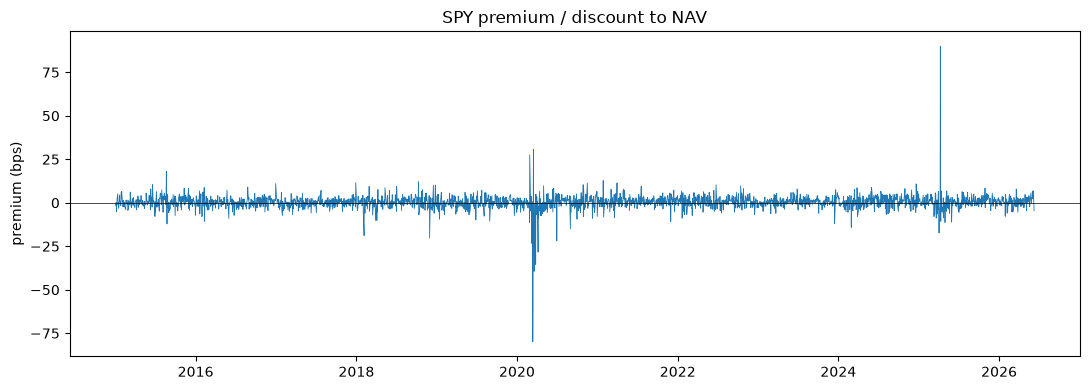

In [2]:
if HAS_DATA:
    spy = prem["SPY"].dropna() * 1e4  # bps
    summ = pd.Series({"mean": spy.mean(), "std": spy.std(),
                      "min": spy.min(), "max": spy.max()}, name="SPY premium (bps)")
    display(summ.to_frame())

    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(spy.index, spy.values, lw=.6)
    ax.axhline(0, color="k", lw=.5); ax.set_ylabel("premium (bps)")
    ax.set_title("SPY premium / discount to NAV"); plt.tight_layout(); plt.show()
else:
    print("Add etf_arb_data.xlsx to compute SPY premium stats and plot.")

**How closely does SPY trade to its NAV on a typical day?** Very closely. Across the full sample, SPY's premium/discount averages **0.30 bps** (essentially zero) with a standard deviation of **4.23 bps** — on a normal day it sits within a few basis points of NAV. The tails are wider than "always tiny," though: the range runs from **−79.8 bps** (discount) to **+90.0 bps** (premium), reflecting brief windows of market stress (notably March 2020) when even SPY's arbitrage mechanism strained. Still, relative to typical trading costs, SPY is pinned tightly to NAV almost all the time — one of the most efficiently arbitraged securities in the world.

### 1.2 Arbitrage trade at a 0.50% premium (one creation unit = 50,000 shares)

SPY is **rich** (price > NAV). The authorized participant (AP) does a **creation**:

1. **Buy** the underlying S&P 500 basket in the open market (cost ≈ NAV per unit).
2. **Deliver** that basket to the ETF sponsor and **receive** one creation unit = 50,000 new SPY shares (in-kind, no cash P&L on this leg).
3. **Sell** the 50,000 SPY shares in the market at the premium price.

Net position: long the cheap basket, short the rich ETF — captured at creation. Gross profit ≈ premium × NAV × shares.

In [3]:
PREMIUM = 0.005
SHARES = 50_000
nav_recent = float(nav["SPY"].dropna().iloc[-1]) if HAS_DATA else 600.0
if not HAS_DATA:
    print(f"(placeholder NAV = {nav_recent})")

gross = PREMIUM * nav_recent * SHARES
print(f"Most recent SPY NAV : {nav_recent:,.2f}")
print(f"Notional per unit   : {nav_recent*SHARES:,.0f}")
print(f"Gross arb profit    : {gross:,.0f}")

Most recent SPY NAV : 737.39
Notional per unit   : 36,869,280
Gross arb profit    : 184,346


### 1.3 Breakeven premium with costs ($3,000 creation fee + 3 bps trading cost)

In [4]:
CREATE_FEE = 3_000
TRADE_BPS = 3e-4
notional = nav_recent * SHARES

breakeven = CREATE_FEE / notional + TRADE_BPS
print(f"Fixed fee as % of notional : {CREATE_FEE/notional*1e4:,.2f} bps")
print(f"Trading cost               : {TRADE_BPS*1e4:,.2f} bps")
print(f"Breakeven premium          : {breakeven*1e4:,.2f} bps  ({breakeven*100:.4f}%)")
if HAS_DATA:
    print(f"\nSPY premium std (1.1)      : {spy.std():,.2f} bps")
    print(f"SPY premium max (1.1)      : {spy.max():,.2f} bps")

Fixed fee as % of notional : 0.81 bps
Trading cost               : 3.00 bps
Breakeven premium          : 3.81 bps  (0.0381%)

SPY premium std (1.1)      : 4.23 bps
SPY premium max (1.1)      : 90.04 bps


**Breakeven vs 1.1.** The breakeven premium comes out to about **3.8 bps** — essentially the same order as SPY's full-sample standard deviation (4.2 bps) and far below the largest observed premium (90.0 bps). Since the premium is clustered near its ~0.3 bp mean, on a typical day it rarely clears 3.8 bps net of costs, so there's usually no trade to do. It's only in the tails — stress episodes where the premium blows out to tens of bps — that the creation trade clears breakeven comfortably.

**What keeps SPY in such a tight band?** Continuous competition among many APs. The instant the premium/discount grows large enough to clear the breakeven cost, APs create (or redeem) and arbitrage it away. Because SPY's underlying basket is deep, liquid, and cheap to trade, breakeven is tiny and the price is pinned to NAV within a few basis points — except in brief episodes (like March 2020) when trading frictions widen enough to let the premium/discount run past that threshold before it gets arbitraged back in.

## 2. HYG in March 2020

### 2.1 HYG premium / discount through 2020

Deepest discount : -127.4 bps on 2020-03-20
Largest premium  : 458.4 bps on 2020-04-09


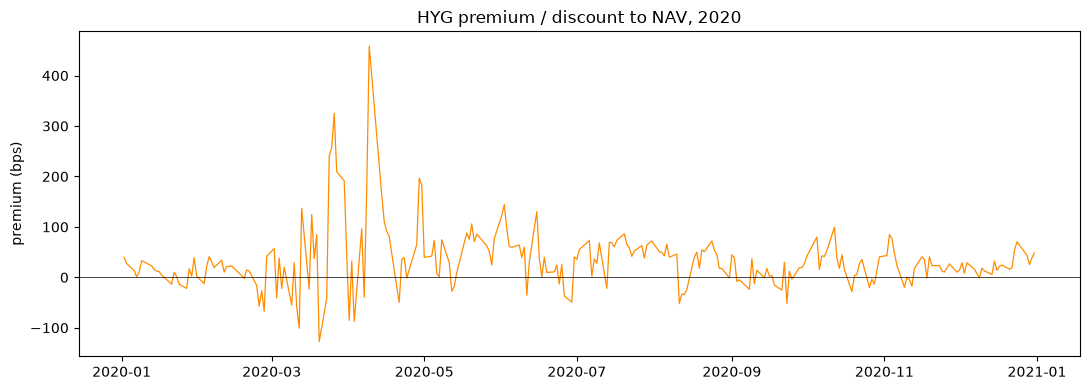

In [5]:
if HAS_DATA:
    hyg = prem["HYG"].dropna() * 1e4
    hyg20 = hyg.loc["2020"]
    lo, hi = hyg20.idxmin(), hyg20.idxmax()
    print(f"Deepest discount : {hyg20.min():,.1f} bps on {lo.date()}")
    print(f"Largest premium  : {hyg20.max():,.1f} bps on {hi.date()}")

    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(hyg20.index, hyg20.values, lw=.9, color="darkorange")
    ax.axhline(0, color="k", lw=.5); ax.set_ylabel("premium (bps)")
    ax.set_title("HYG premium / discount to NAV, 2020"); plt.tight_layout(); plt.show()
else:
    print("Add etf_arb_data.xlsx to compute HYG 2020 extremes and plot.")

### 2.2 The redemption trade — is it an arbitrage?

The apparent trade: buy HYG cheap at a discount, redeem a creation unit for the underlying high-yield bonds, and sell those bonds at the NAV marks.

**It is not clean arbitrage.** At least two reasons the March-2020 discount was not free money:

1. **Stale / non-executable NAV.** HYG's NAV is struck from *quoted* marks on high-yield bonds, many of which barely traded during the March-2020 freeze. Those marks were stale and above where bonds could actually be sold. You could not realize the NAV — the true, tradable value of the bonds was near the ETF price, not the NAV.
2. **Liquidity and execution risk on the bond leg.** Redeeming leaves you holding a basket of illiquid HY bonds you must sell into a market with almost no bids and enormous bid/ask spreads. Prices could (and did) keep falling during settlement, and dealer balance sheets were full — so the "profit" could evaporate or turn negative before you unwound.

(Add to these creation/redemption fees and capital-at-risk over the settlement window.) The discount was compensation for bearing real illiquidity, not a mispricing.

### 2.3 Price vs NAV — which was more accurate?

During the discount, the **ETF price** was the more accurate measure of fair value. HYG traded continuously on-exchange with real buyers and sellers, so its price reflected live, executable value; the **NAV** was built from stale bond marks that lagged the sell-off.

**April 2020 confirms this.** After the Fed announced it would buy corporate credit (including HY ETFs), HYG swung to a **premium** to NAV. The ETF price jumped immediately on the new information while the lagging bond marks caught up only later — so the ETF again led price discovery. In both directions (down in March, up in April) the ETF price moved first and the NAV followed, showing the ETF, not the NAV, carried the accurate real-time signal.